# Lab 11: Ensembles

In this lab we further experiment with the task of predicting which brand of orange juice a customer would buy.

We'll use the same [`OJ.csv` dataset](https://www.rdocumentation.org/packages/ISLR2/versions/1.3-1/topics/OJ) we used in the last two labs. It should already be there in your data folder from the last lab. If not, you can get the data file from [our course data folder](https://drive.google.com/drive/folders/1YBxtx7KILtcw6mFEkKmznaRASUHPLjI2?usp=sharing).

The data set has the following columns:

1. `Purchase` (the **target**): A categorical variable with levels CH and MM indicating whether the customer purchased Citrus Hill or Minute Maid Orange Juice
1. `WeekofPurchase`: Week of purchase
1. `StoreID`: Store ID
1. `PriceCH`: Price charged for CH
1. `PriceMM`: Price charged for MM
1. `DiscCH`: Discount offered for CH
1. `DiscMM`: Discount offered for MM
1. `SpecialCH`: Indicator of special on CH
1. `SpecialMM`: Indicator of special on MM
1. `LoyalCH`: Customer brand loyalty for CH
1. `SalePriceMM`: Sale price for MM
1. `SalePriceCH`: Sale price for CH
1. `PriceDiff`: Sale price of MM less sale price of CH
1. `Store7`: A categorical variable with levels No and Yes indicating whether the sale is at Store 7
1. `PctDiscMM`: Percentage discount for MM
1. `PctDiscCH`: Percentage discount for CH
1. `ListPriceDiff`: List price of MM less list price of CH
1. `STORE`: Which of 5 possible stores the sale occured at

The outline of the lab is as follows:
1. Load, clean, split data
1. Voting approaches
1. Bagging and random forest
1. Boosting

## Load, clean, and split dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# drive_url = 'https://drive.google.com/file/d/1YiwMCQSxfD4ZVKCPzHUNl5ocdcvYXeZd/view?usp=drive_link'
file_url = 'https://drive.google.com/uc?id=1YiwMCQSxfD4ZVKCPzHUNl5ocdcvYXeZd'

rawdata = pd.read_csv(file_url)
data = rawdata.astype({'Purchase': 'category', 'StoreID':'category', 'SpecialCH':'category', 'SpecialMM':'category', })
data.drop(['Store7', 'STORE'], axis=1, inplace=True)
data.head()

,Purchase,WeekofPurchase,StoreID,PriceCH,PriceMM,DiscCH,DiscMM,SpecialCH,SpecialMM,LoyalCH,SalePriceMM,SalePriceCH,PriceDiff,PctDiscMM,PctDiscCH,ListPriceDiff
0,CH,237,1,1.75,1.99,0.00,0.0,0,0,0.500000,1.99,1.75,0.24,0.000000,0.000000,0.24
1,CH,239,1,1.75,1.99,0.00,0.3,0,1,0.600000,1.69,1.75,-0.06,0.150754,0.000000,0.24
2,CH,245,1,1.86,2.09,0.17,0.0,0,0,0.680000,2.09,1.69,0.40,0.000000,0.091398,0.23
3,MM,227,1,1.69,1.69,0.00,0.0,0,0,0.400000,1.69,1.69,0.00,0.000000,0.000000,0.00
4,CH,228,7,1.69,1.69,0.00,0.0,0,0,0.956535,1.69,1.69,0.00,0.000000,0.000000,0.00


We are using label encoder to convert outcome to 0/1 because some of the methods in `VotingClassifiers` we want to illustrate are not handling categorical outcome correctly. It is not always necessary.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X = data.drop('Purchase', axis=1) # separate X ...
y = data['Purchase'] # from y
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size = .2, random_state=0) #split all
train_y = le.fit_transform(train_y)
test_y = le.transform(test_y)
train_X.shape, test_X.shape, train_y.shape, test_y.shape # check sizes


((856, 15), (214, 15), (856,), (214,))

We'll use a pipeline to carry out some standard preprocessing, because we'll use a variety of models in this lab. This common preprocessing ensures that all of them work.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer, make_column_selector

from sklearn import set_config
set_config(display='diagram') # shows the pipeline graphically when printed

num_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])
cat_pipeline = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('cat_encoder', OneHotEncoder(drop='first'))
    ])

prep_pipeline = ColumnTransformer([
    ('num', num_pipeline, make_column_selector(dtype_include=np.number)),
    ('cat', cat_pipeline, make_column_selector(dtype_include='category'))
], verbose_feature_names_out=False)

prep_pipeline

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x780e8778ecf0>),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('cat_encoder',
                                                  OneHotEncoder(drop='first'))]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x780e87dd7770>)],
                  verbose_feature_names_out=False)

We'll clean and prepare the data once and use it, so that we can experiment with individual ensembles, without having to reach inside the pipeline to access the models. In a production environment, when preprocessing might have hyper parameters (e.g., the type we had in lab 3), you may want to place the ensembles inside the pipeline (like we did in the SVM and other labs).

In [ ]:
# preprocess the training data
tr_X = prep_pipeline.fit_transform(train_X)
tr_y = train_y

# preprocess the test data
t_X = prep_pipeline.transform(test_X)
t_y = test_y

# check sizes
train_X.shape, tr_X.shape, tr_y.shape, t_X.shape, t_y.shape

((856, 15), (856, 18), (856,), (214, 18), (214,))

## Voting and Stacking

Voting classifiers allow us to combine the predictions of very different classifiers, as seen below. Here, and in the rest of this lab, we'll learn from the training data and apply on the test data to see how good they are. Again, this is a departure from your typical ML project process where you'd typically set aside test data for final estimation of the generalization error of the *selected model*. We are simply becoming familiar with various ensemble techniques, not selecting among them in this lab.

In [ ]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svc', SVC(random_state=42, probability=True))
    ], voting='hard'  # default
    # Default is hard voting, but you can use soft voting by passing voting = 'soft'. Each model's
    # vote can be further modified using 'weights' parameter (equal weight by default).
)

voting_clf.fit(tr_X, tr_y)  # fit each member model and keep it for application

VotingClassifier(estimators=[('lr', LogisticRegression(random_state=42)),
                             ('dt', DecisionTreeClassifier(random_state=42)),
                             ('svc', SVC(probability=True, random_state=42))])

In [ ]:
for name, clf in voting_clf.named_estimators_.items():
    print(f'Accuracy of {name} is {clf.score(t_X, t_y):.4f}')

print(f'Them voting give {voting_clf.score(t_X, t_y):.4f}')

Accuracy of lr is 0.8224
Accuracy of dt is 0.7804
Accuracy of svc is 0.8224
Them voting give 0.8271


In this example we get a small improvement in performance, but that doesn't always happen.

Next, we'll use the stacking approach. This has many similarity with the voting classifiers (allows different types of models, predicts based on their votes), but it differs in that it seeks to learn how to use each vote (e.g., how much weight if we combine using linear regression).

In [ ]:
from sklearn.ensemble import StackingClassifier, RandomForestClassifier

stacking_clf = StackingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42)),
        ('dt', DecisionTreeClassifier(random_state=42)),
        ('svc', SVC(random_state=42))
        # Using soft votes as inputs into stacking often works well (default).
        # Often it's the probability of classification, or a decision function.
    ],
    passthrough=False, # Default, don't have to mention. Use only the predictions in blender.
      # If you turn it into True, passes all the input features with the prediction to the blender.
    final_estimator=RandomForestClassifier(random_state=42), # blender
      # This is the meta model that learns how to combine them.
    cv=5  # number of cross-validation folds for each of the weak/component models
)
stacking_clf.fit(tr_X, tr_y)

print(f'Stacking the three has accuracy of {stacking_clf.score(t_X, t_y):.4f}')

Stacking the three has accuracy of 0.8084


## Bagging and Random Forest

In the previous section all classifiers were of different types, but only three votes were combined. What if you want to combine 100s? Bagging allows us to get there, by using 100s of models of the *same type* but trained with different data.

In [ ]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

bag_clf = BaggingClassifier(DecisionTreeClassifier(), # Can use a different model, but trees are fast
                            n_estimators=500, # more don't overfit, but slow down, with diminishing gain
                            oob_score=True, # to produce out of bag test score
                            random_state=42)
bag_clf.fit(tr_X, tr_y) # train
print(f'Bagging {bag_clf.n_estimators} trees leads to accuracy of {bag_clf.score(t_X, t_y):.4f}.')

Bagging 500 trees leads to accuracy of 0.7991.


We could have used 500 logistic regressions, trained on 500 bootstrapped samples, or SVMs. Btw, you could use a different subset of features (instead of default of all) to further diversify the weak learners. Is there a parameter you can use? How does it affect the performance of the model? (**exercise**).

Our accuracy through out-of-bag testing was:

In [ ]:
print(f'The out-of-bag accuracy from using {bag_clf.n_estimators} trees is {bag_clf.oob_score_:.4f}')

The out-of-bag accuracy from using 500 trees is 0.8037


This is close. Note, we didn't "use up" our test data, but used the unused portion of the training data to measure this.
Neither did we have to do expensive cross validation (training forest five times or so).

This is from out-of-sample prediction, but one limitation is no prediction is made with the *final* ensemble; prediction on each record is made with the subset of models (about a third, different subset for each record) that didn't train on it. So, it'll not be exactly the same, often it'll underestimate accuracy.

Despite this, out-of-bag error is useful for model selection (the relative performances hold, even if absolute performances do not).

Random Forest diversifies the trees a bit by considering different subsets of features at each node (not just each tree/model that is possible to achieve using `BaggingClassifier`).

In [ ]:
# @title Random Forest { run: "auto" }

from sklearn.ensemble import RandomForestClassifier

n_trees = 100   #@param {type:"slider", min:20, max:100, step:10}
leaves  = 16     #@param {type:"slider", min:2, max:100, step:1}

rnd_clf = RandomForestClassifier(n_estimators=n_trees, max_leaf_nodes=leaves,
                                 max_features="sqrt", # consider sqrt(n_features) randomly selected features at each node
                                 n_jobs=-1, random_state=42,
                                 oob_score=True)
rnd_clf.fit(tr_X, tr_y)
print(f'Random forest of {rnd_clf.n_estimators} trees leads to accuracy of {rnd_clf.score(t_X, t_y):.4f}.')
print(f'The out-of-bag accuracy from using {rnd_clf.n_estimators} trees is {rnd_clf.oob_score_:.4f}')

Random forest of 100 trees leads to accuracy of 0.8364.
The out-of-bag accuracy from using 100 trees is 0.8271


This random forest predicts better than other ensembles we have considered before, but this is very sensitive to the structure of the weak learner decision trees. We controlled the size of the decision tree by setting maximum number of leaves to 16. There are other parameters that you can use to achieve similar effect; we'd often have to experiment with them a bit to get good results (Experiment in this problem).

Although, Random Forests work well in practice, one of the main criticisms is that we lose the nice interpretability of a decision tree when we combine hundreds of them. This can be salvaged a little bit by examining the feature importances. Random forests produce them by measuring the average decrease in impurity (RSS or Gini) when data were split based on each feature. This is normalized and stored in feature importance vector.

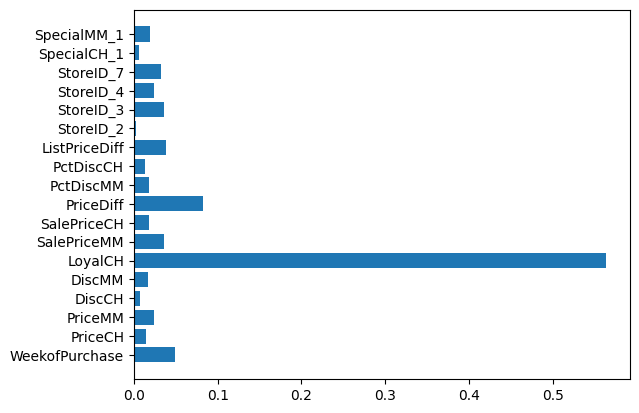

In [ ]:
feature_importances = rnd_clf.feature_importances_
feature_names = prep_pipeline.get_feature_names_out()
plt.barh(feature_names, feature_importances);

## Boosting
So far, all the ensemble's weak learners have been learnt independent of each other. In fact, one strength of the above mentioned approaches is that they can learn components in parallel. The downside is each component is unaware of the weakness of the others, thus can't "cover for it". Boosting fixes that by learning sequentially.

We learn models in iterations. Each model learns such that the data records where the previous models predicted poorly get a higher weight/priority. Each model is added to the previous models after being scaled by a small factor called learning rate (usually in the range of .01 to 0.1). Smaller the learning rate, larger the number of iterations (component models) we need. The mathematical details vary across types of boosting models and across classification to regression exercises.

There are many different boosting models, but we'll use the latest of the set in scikit learn: Histogram based Gradient Boosting Classifier. This implementation is "orders of magnitude faster" than other boosting implementation in `sklearn`. It also has the advantage that it can handle missing values without any preprocessing. Though the categorical data are natively supported, it still needs to be told which columns are categorical ([example](https://scikit-learn.org/stable/auto_examples/ensemble/plot_gradient_boosting_categorical.html)). We'll keep the code in this lab simple and consistent with the rest by using the preprocessed data.

In [ ]:
# @title Gradient Boosting { run: "auto" }
from sklearn.ensemble import HistGradientBoostingClassifier

max_iter = 100  #@param {type:"slider", min:5, max:100, step:5}
hgb_clf = HistGradientBoostingClassifier(max_leaf_nodes=16, max_iter=max_iter, learning_rate=.1) # λ
hgb_clf.fit(tr_X, tr_y)
print(f'Gradient boosting with {hgb_clf.max_iter} trees leads to accuracy of {hgb_clf.score(t_X, t_y):.4f}.')

Gradient boosting with 100 trees leads to accuracy of 0.7850.


Boosting can overfit if we create too many weak learners: since each is fitted to the error left by the previous one, at some point it'll fit to noise. Try increasing the number of iterations above to see this.

It too is sensitive to the complexity of the decision trees learnt in the components. Often it's a good idea to search for the best hyper-parameter values.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint

param_grid = {'max_leaf_nodes': randint(2, 16),     # for each weak learner tree
              'max_iter': randint(2, 64),           # number of weak learners
              'learning_rate': loguniform(1e-2, 1)} # multiply with the weak learner before adding

rand_search = RandomizedSearchCV(HistGradientBoostingClassifier(random_state=42),
                                 param_grid, cv=5, n_iter = 50, scoring='accuracy',
                                 random_state=42)

rand_search.fit(tr_X, tr_y)
rand_cv_res = pd.DataFrame(rand_search.cv_results_)
rand_cv_res.sort_values(by="mean_test_score", ascending=False, inplace=True)
rand_cv_res.filter(regex = '(^param_|mean_test_score)', axis=1).head()

,param_learning_rate,param_max_iter,param_max_leaf_nodes,mean_test_score
2,0.077923,24,12,0.821277
19,0.097803,48,4,0.821277
32,0.941399,25,2,0.820080
3,0.082889,54,5,0.817768
48,0.042532,33,5,0.815436


We see that in general, many small trees seem to work well.

eXtreme Gradient Boosted Trees (**XGBoost**) have made quite a bit of name for themselves in recent years. They are evolution of the Gradient Boosted Trees that directly penalize complex trees. Additionally, they incorporate some optimizations that make them suitable for large datasets (for instance, learning of each tree can use parallel processing).

In [ ]:
from xgboost import XGBClassifier

# We'll need to use a portion of the training data as 'validation' data to determine how many trees to grow
tr_X_tr, tr_X_v, tr_y_tr, tr_y_v = train_test_split(tr_X, tr_y, test_size = .2, random_state=0)

bst = XGBClassifier(n_estimators=100, # up to 100 trees
                    max_leaves=16, # each will have at most 16 leaves
                    learning_rate=0.1,
                    eval_metric='error',
                    early_stopping_rounds=10, # stop if validation error doesn't improve for 10 iterations
                    objective='binary:logistic') # learning a binary classifier, produce probability as score
bst.fit(tr_X_tr, tr_y_tr, eval_set=[(tr_X_v, tr_y_v)], verbose=False)

print(f'The accuracy of XGBoost is {bst.score(t_X, t_y):.4f}.')


The accuracy of XGBoost is 0.8271.


**Exercise**

Apply these techniques to predict college Apps, in the `College.csv` dataset we saw in the lab for feature selection. Note, that'd be a regression exercise. So, you'd need to be careful with the specific scikit learn classes and in some cases objective functions. They need to be appropriate for the regression problem.
1. What strategy led to the highest out-of-sample $R^2$?
1. What were the three most important features in the model that achieves it?

In [ ]:
df = pd.read_csv("College.csv")
df

,Unnamed: 0,Private,Apps,Accept,Enroll,Top10perc,Top25perc,F.Undergrad,P.Undergrad,Outstate,Room.Board,Books,Personal,PhD,Terminal,S.F.Ratio,perc.alumni,Expend,Grad.Rate
0,Abilene Christian University,Yes,1660,1232,721,23,52,2885,537,7440,3300,450,2200,70,78,18.1,12,7041,60
1,Adelphi University,Yes,2186,1924,512,16,29,2683,1227,12280,6450,750,1500,29,30,12.2,16,10527,56
2,Adrian College,Yes,1428,1097,336,22,50,1036,99,11250,3750,400,1165,53,66,12.9,30,8735,54
3,Agnes Scott College,Yes,417,349,137,60,89,510,63,12960,5450,450,875,92,97,7.7,37,19016,59
4,Alaska Pacific University,Yes,193,146,55,16,44,249,869,7560,4120,800,1500,76,72,11.9,2,10922,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
772,Worcester State College,No,2197,1515,543,4,26,3089,2029,6797,3900,500,1200,60,60,21.0,14,4469,40
773,Xavier University,Yes,1959,1805,695,24,47,2849,1107,11520,4960,600,1250,73,75,13.3,31,9189,83
774,Xavier University of Louisiana,Yes,2097,1915,695,34,61,2793,166,6900,4200,617,781,67,75,14.4,20,8323,49
775,Yale University,Yes,10705,2453,1317,95,99,5217,83,19840,6510,630,2115,96,96,5.8,49,40386,99


In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# 1. Load data
df = pd.read_csv("College.csv")  # adjust path if needed

# If there is an unnamed first column with college names, drop it
if df.columns[0].lower().startswith("unnamed"):
    df = df.drop(columns=df.columns[0])

# Target & features
y = df["Apps"]
X = df.drop(columns=["Apps"])

# Make sure Private is treated as categorical
if "Private" in X.columns:
    X["Private"] = X["Private"].astype("category")

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Preprocessing: numeric + categorical
num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

prep = ColumnTransformer([
    ("num", num_pipe, make_column_selector(dtype_include=np.number)),
    ("cat", cat_pipe, make_column_selector(dtype_include="category"))
])

Define ensemble regressors

In [ ]:
from sklearn.ensemble import (
    BaggingRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor
)
from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import StackingRegressor, VotingRegressor

# Base models
bag_reg = Pipeline([
    ("prep", prep),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

rf_reg = Pipeline([
    ("prep", prep),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_features="sqrt",
        random_state=42,
        n_jobs=-1
    ))
])

hgb_reg = Pipeline([
    ("prep", prep),
    ("model", HistGradientBoostingRegressor(
        max_leaf_nodes=16,
        learning_rate=0.1,
        max_iter=200,
        random_state=42
    ))
])

# (Optional) stacking & voting
stack_reg = Pipeline([
    ("prep", prep),
    ("model", StackingRegressor(
        estimators=[
            ("lr", LinearRegression()),
            ("rf", RandomForestRegressor(
                n_estimators=150, random_state=42, n_jobs=-1
            )),
            ("hgb", HistGradientBoostingRegressor(
                max_leaf_nodes=16, learning_rate=0.1,
                max_iter=200, random_state=42
            ))
        ],
        final_estimator=RandomForestRegressor(
            n_estimators=100, random_state=42, n_jobs=-1
        ),
        n_jobs=-1
    ))
])

vote_reg = Pipeline([
    ("prep", prep),
    ("model", VotingRegressor([
        ("rf", RandomForestRegressor(
            n_estimators=200, random_state=42, n_jobs=-1
        )),
        ("hgb", HistGradientBoostingRegressor(
            max_leaf_nodes=16, learning_rate=0.1,
            max_iter=200, random_state=42
        ))
    ]))
])

models = {
    "Bagging (Tree)": bag_reg,
    "Random Forest": rf_reg,
    "HistGB (Boosting)": hgb_reg,
    "Stacking": stack_reg,
    "Voting": vote_reg
}

Compare out-of-sample R² for each strategy

In [ ]:
from sklearn.metrics import r2_score

cv_results = {}

for name, pipe in models.items():
    scores = cross_val_score(
        pipe, X_train, y_train,
        cv=5, scoring="r2", n_jobs=-1
    )
    cv_results[name] = scores
    print(f"{name:15s} CV R²: mean={scores.mean():.3f}, std={scores.std():.3f}")

Bagging (Tree)  CV R²: mean=0.876, std=0.094
Random Forest   CV R²: mean=0.860, std=0.092
HistGB (Boosting) CV R²: mean=0.820, std=0.104
Stacking        CV R²: mean=0.873, std=0.074
Voting          CV R²: mean=0.862, std=0.101


In [ ]:
# choose the best model name based on printed CV results
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
best_model = models[best_name]

print("\nBest model based on CV:", best_name)

best_model.fit(X_train, y_train)
y_pred_test = best_model.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)
print(f"Test R² of best model ({best_name}): {test_r2:.3f}")


Best model based on CV: Bagging (Tree)
Test R² of best model (Bagging (Tree)): 0.925


Get the top 3 most important features from the best model

In [ ]:
# Fit preprocessing separately to get feature names
prep.fit(X_train)
X_train_prep = prep.transform(X_train)

# Get feature names after encoding
num_feats = prep.named_transformers_["num"].get_feature_names_out()
cat_feats = prep.named_transformers_["cat"].named_steps["encoder"].get_feature_names_out(
    make_column_selector(dtype_include="category")(X)
)
feature_names = np.concatenate([num_feats, cat_feats])

# Refit the *regressor only* on preprocessed data for importance
if best_name == "Random Forest":
    reg = RandomForestRegressor(
        n_estimators=300, max_features="sqrt",
        random_state=42, n_jobs=-1
    )

elif best_name == "HistGB (Boosting)":
    reg = HistGradientBoostingRegressor(
        max_leaf_nodes=16, learning_rate=0.1,
        max_iter=200, random_state=42
    )

elif best_name == "Bagging (Tree)":
    reg = BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    )

else:
    reg = None  # stacking/voting or models without feature importance
    print("Model does not support feature importance.")


# ---- FIX: feature importance for Bagging or other models ----
if reg is not None:
    reg.fit(X_train_prep, y_train)

    # Case 1: BaggingRegressor → average all base estimators
    if isinstance(reg, BaggingRegressor):
        # Make sure estimator has attribute feature_importances_
        tree_importances = np.array([
            est.feature_importances_
            for est in reg.estimators_
            if hasattr(est, "feature_importances_")
        ])
        importances = tree_importances.mean(axis=0)

    # Case 2: Models with direct feature_importances_
    elif hasattr(reg, "feature_importances_"):
        importances = reg.feature_importances_

    else:
        print("This model does not provide feature importances.")
        importances = None

    # Output results
    if importances is not None:
        imp_series = pd.Series(importances, index=feature_names).sort_values(ascending=False)

        print("\nTop 10 features by importance:")
        print(imp_series.head(10))

        print("\nTop 3 important features:")
        print(imp_series.head(3))



Top 10 features by importance:
Accept         0.917834
Top10perc      0.019215
Top25perc      0.010705
Enroll         0.008273
F.Undergrad    0.006910
Outstate       0.006022
Expend         0.005864
Grad.Rate      0.004843
perc.alumni    0.003164
S.F.Ratio      0.003085
dtype: float64

Top 3 important features:
Accept       0.917834
Top10perc    0.019215
Top25perc    0.010705
dtype: float64


The model achieving the best out-of-sample R² identified “Accept” as overwhelmingly the most important predictor of the number of college applications (Apps). Its importance value (≈0.918) is dramatically larger than any other feature, indicating that the number of students accepted strongly determines the number of students who apply. This makes intuitive sense: institutions with a history of accepting more students tend to attract more applications, and “Accept” is also naturally correlated with institutional size and popularity.

The second and third most important variables are Top10perc and Top25perc, which describe the academic strength of incoming students. Their positive importance values suggest that colleges attracting higher-achieving students tend to receive more applications. These features typically indicate institutional prestige and selectivity, which directly influence student interest.